# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStsToX)

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

data_path = parent + "/runs/LET_vanad"

with mx.Read(data_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )
display(scipp_data_group)
det_positions = scipp_data_group["positions"]

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 25886}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [2]:
events_binned = scipp_data_group["events"]
display(events_binned)
sample_position = events_binned.coords["sample_position"]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:25886, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30053, 30054]
* position                  vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.3436, 1.98529, 22.4005), (2.30641, 1.98529, 22.3674)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

# Read in Monitor data (MsStasScript/McStasToX)

In [3]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_single_pulse

mcstas_data = ms.load_data(data_path)
presample_monitor_data = ms.name_search("Monitor6", mcstas_data)
monitor_data = monitor_single_pulse(presample_monitor_data)

with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="Monitor6"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:1, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [3.67905]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33248)]
  presample_monitor_position  vector3              [m]  ()  (0, 0, 23.505)
  sample_position           vector3              [m]  ()  (0, 0, 25)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.0280169]
* time_on_sample            float64              [s]  (rrm)  [0.0297989]
Data:
                            float64         [counts]  (rrm)  [41770.6]

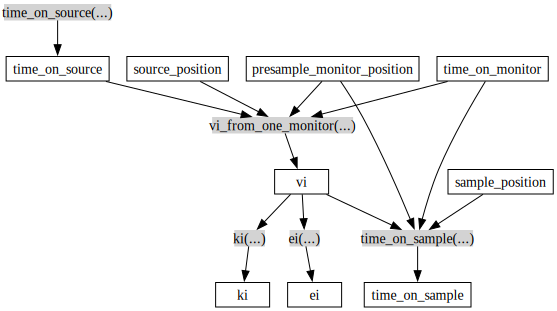

In [4]:
from dgs_reduction import calculate_ei

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [5]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:30056, rrm:1, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.26876, 1.98529, 22.3349)]
* ei                        float64            [meV]  (rrm)  [3.67905]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33248)]
* monitor_counts            float64         [counts]  (rrm)  [41770.6]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (rrm)  [0.0297989]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.0405236, 0.0405236, ..., 0.0405236, 0.0405236]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333738, 0.0333738, ..., 0.0333738, 0.0333738]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [6]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
* toa                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [7]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
* ei                        float64            [meV]  (events)  [3.67905, 3.67905, ..., 3.67905, 3.67905]
* ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33248), (0, 0, 1.33248), ..., (0, 0, 1.33248), (0, 0, 1.33248)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
* rrm                         int64  [dimensionless]  (events)  [0, 0, ..., 0, 0]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (events)  [0.0297989, 0.0297989, ..., 0.0297989, 0.0297989]
* toa                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
  ef                        float64            [meV]  (events)  [3.74393, 3.75285, ..., 3.80402, 3.54051]
  ei                        float64            [meV]  (events)  [3.67905, 3.67905, ..., 3.67905, 3.67905]
* en                        float64            [meV]  (events)  [-0.0648848, -0.0738023, ..., -0.12497, 0.138534]
* kf                        vector3           [1/Å]  (events)  [(-0.745151, -0.663191, 0.900964), (-0.73314, -0.663981, 0.91255), ..., (0.776619, 0.668492, -0.886446), (0.749238, 0.644923, -0.855193)]
  ki                        vector3           [1/Å]  (events)  [(0, 0, 1.33248), (0, 0, 1.33248), ..., (0, 0, 1.33248), (0, 0, 1.33248)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
  q                         vector3           [1/Å]  (events)  [(0.745151, 0.663191, 0.431513), (0.73314, 0.663981, 0.419927), ..., (-0.776619, -0.668492, 2.21892), (-0.749238, -0.644923, 2.18767)]
* q_mag                     float64           [1/Å]  (events)  [1.08686, 1.07457, ..., 2.4441, 2.40066]
* qx                        float64           [1/Å]  (events)  [0.745151, 0.73314, ..., -0.776619, -0.749238]
* qy                        float64           [1/Å]  (events)  [0.663191, 0.663981, ..., -0.668492, -0.644923]
* qz                        float64           [1/Å]  (events)  [0.431513, 0.419927, ..., 2.21892, 2.18767]
* rrm                         int64  [dimensionless]  (events)  [0, 0, ..., 0, 0]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  time_on_sample            float64              [s]  (events)  [0.0297989, 0.0297989, ..., 0.0297989, 0.0297989]
  toa                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
  vf                        vector3            [m/s]  (events)  [(-469.163, -417.56, 567.267), (-461.601, -418.057, 574.562), ..., (488.977, 420.897, -558.126), (471.737, 406.058, -538.449)]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

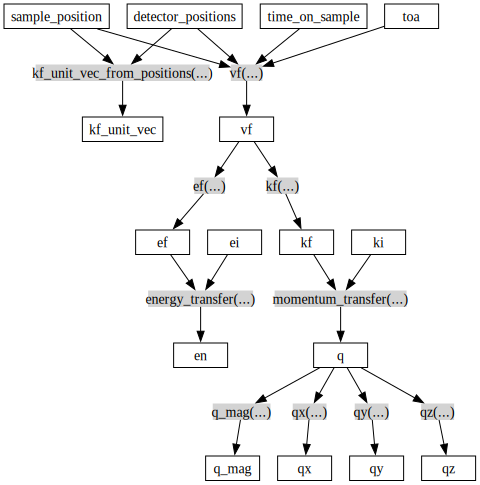

In [8]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Plot events to check for coverage
Notice here we do not ditinguish diffferent RRMs, all events are used for histogramming

In [9]:
%matplotlib widget
import plopp as pp
from dgs_reduction import generate_bins, generate_plot_coords_and_title

bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-2, 2, 0.1),
    qz=(-1.0, 1.0),
    en=(-0.2, 0.2),
)

display(bins)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    title=plot_title,
)

{'qx': <scipp.Variable> (qx: 36)    float64           [1/Å]  [-2, -1.9, ..., 1.4, 1.5],
 'qy': <scipp.Variable> (qy: 41)    float64           [1/Å]  [-2, -1.9, ..., 1.9, 2],
 'qz': <scipp.Variable> (qz: 2)    float64           [1/Å]  [-1, 1],
 'en': <scipp.Variable> (en: 2)    float64            [meV]  [-0.2, 0.2]}

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:40, qz:1, en:1, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-0.2, 0.2]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1, 1]
  sample_position           vector3              [m]  ()  (0, 0, 25)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [10]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-1.0, 1.0),
    qz=(-0.5, 2.5),
    en=(-1, 1, 0.02),
)
plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    # vmax=20,
    title=plot_title,
)

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:1, qz:1, en:100, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.98, ..., 0.98, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
  sample_position           vector3              [m]  ()  (0, 0, 25)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [11]:
bins = generate_bins(
    qx=(-1.5, 1.0),
    qy=(-1.0, 1.0),
    qz=(-0.5, 2.5, 0.1),
    # en=(-4, 5, 0.02),
    en=(-1, 1, 0.02),
)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    # vmax=20,
    title=plot_title,
)

<scipp.DataArray>
Dimensions: Sizes[qx:1, qy:1, qz:30, en:100, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.98, ..., 0.98, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, -0.4, ..., 2.4, 2.5]
  sample_position           vector3              [m]  ()  (0, 0, 25)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [12]:
van_path = parent + "/runs/LET_vanad"

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)
# solid angles
d_omega = v_events.hist().data
d_omega /= d_omega.sum()
norm_factors.coords["d_omega"] = d_omega

<scipp.DataArray>
Dimensions: Sizes[pixel_id:25886, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30053, 30054]
* position                  vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.3436, 1.98529, 22.4005), (2.30641, 1.98529, 22.3674)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:30056, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30054, 30055]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

In [13]:
# LET banana detectors
# Horizontal -40 to 140 degs, sample to detector distance is R = 3.5 m, 221 bins
# width per pixel is h = pi*R/221 = 0.04975 m
# Vertical height is H = 4 m, 136 bins
# height per pixel is w = H/136 = 0.0394 m
# solid angle Omega = 4*arctan(w*h/(2d*sqrt(4d^2+w^2+h^2)))
# d = sqrt(x^2+y^2+z^2)
import numpy as np

h = sc.norm(det_positions[221] - det_positions[0])
w = sc.norm(det_positions[1] - det_positions[0])
d = sc.norm(det_positions - sample_position)
ratio = w * h / 4 / d / sc.sqrt(d**2 + w**2 / 4 + h**2 / 4)

d_omega_calc = sc.array(dims=["pixel_id"], values=4 * np.arctan(ratio.values))
norm_factors.coords["d_omega_calc"] = d_omega_calc

In [14]:
d_omega_calc

<scipp.Variable> (pixel_id: 30056)    float64  [dimensionless]  [9.03749e-05, 9.03749e-05, ..., 9.03749e-05, 9.03749e-05]

In [15]:
pp.plot(
    {"Van": d_omega, "Calc": d_omega_calc},
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    markersize=2,
    ymax=3e-4,
    ymin=0.0,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [16]:
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:30056, rrm:1, ]
Coordinates:
* d_omega                   float64  [dimensionless]  (pixel_id)  [1.66327e-16, 1.52097e-32, ..., 9.40604e-05, 0]
* d_omega_calc              float64  [dimensionless]  (pixel_id)  [9.03749e-05, 9.03749e-05, ..., 9.03749e-05, 9.03749e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.26876, 1.98529, 22.3349)]
* ei                        float64            [meV]  (rrm)  [3.67905]
* ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33248)]
* monitor_counts            float64         [counts]  (rrm)  [41770.6]
  sample_position           vector3              [m]  ()  (0, 0, 25)
* time_on_sample            float64              [s]  (rrm)  [0.0297989]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.0405236, 0.0405236, ..., 0.0405236, 0.0405236]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333738, 0.0333738, ..., 0.0333738, 0.0333738]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

In [17]:
sc.norm(
    norm_factors.coords["detector_positions"] - norm_factors.coords["sample_position"]
)

<scipp.Variable> (pixel_id: 30056)    float64              [m]  [4.02385, 4.02385, ..., 4.02385, 4.02385]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:30056, rrm:1, ]
Coordinates:
* d_omega                   float64  [dimensionless]  (pixel_id)  [1.66327e-16, 1.52097e-32, ..., 9.40604e-05, 0]
* d_omega_calc              float64  [dimensionless]  (pixel_id)  [9.03749e-05, 9.03749e-05, ..., 9.03749e-05, 9.03749e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.26876, 1.98529, 22.3349)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [6.62228, 6.62228, ..., 6.62228, 6.62228]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [0.735809, 0.735809, ..., 0.735809, 0.735809]
  ei                        float64            [meV]  (rrm)  [3.67905]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.991024, -0.882021, 1.19825), (-0.97389, -0.882021, 1.21222), ..., (1.02469, 0.882021, -1.16959), (1.00796, 0.882021, -1.18404)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [1.78771, 1.78771, ..., 1.78771, 1.78771]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.330341, -0.294007, 0.399417), (-0.32463, -0.294007, 0.404072), ..., (0.341562, 0.294007, -0.389865), (0.335985, 0.294007, -0.394681)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [0.595902, 0.595902, ..., 0.595902, 0.595902]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.554355, -0.493381, 0.670273), (-0.544771, -0.493381, 0.678085), ..., (0.573185, 0.493381, -0.654243), (0.563827, 0.493381, -0.662325)]
  ki                        vector3           [1/Å]  (rrm)  [(0, 0, 1.33248)]
* monitor_counts            float64         [counts]  (rrm)  [41770.6]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(0.991024, 0.882021, 0.134227), (0.97389, 0.882021, 0.120261), ..., (-1.02469, -0.882021, 2.50207), (-1.00796, -0.882021, 2.51652)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(0.330341, 0.294007, 0.93306), (0.32463, 0.294007, 0.928405), ..., (-0.341562, -0.294007, 1.72234), (-0.335985, -0.294007, 1.72716)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  time_on_sample            float64              [s]  (rrm)  [0.0297989]
  toa_max                   float64              [s]  (pixel_id, rrm)  [0.0405236, 0.0405236, ..., 0.0405236, 0.0405236]
  toa_min                   float64              [s]  (pixel_id, rrm)  [0.0333738, 0.0333738, ..., 0.0333738, 0.0333738]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

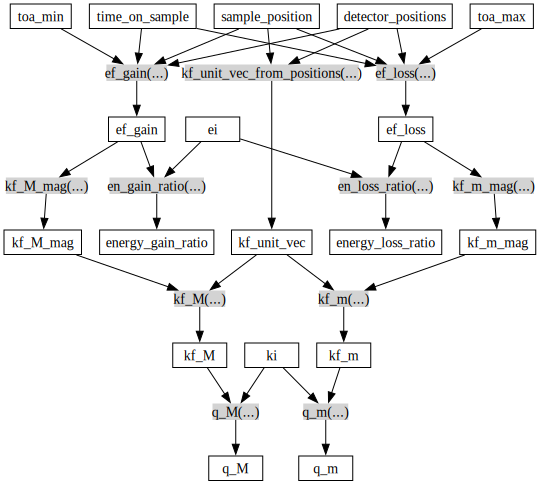

In [18]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

In [19]:
from reduction._single_crystal import compute_q_de_norm

rrm = 0

qm = norm_factors.coords["q_m"]["rrm", rrm]
qM = norm_factors.coords["q_M"]["rrm", rrm]
kf_m = norm_factors.coords["kf_m_mag"]["rrm", rrm]
kf_M = norm_factors.coords["kf_M_mag"]["rrm", rrm]

trajectory_start = (qm.fields.x.copy(), qm.fields.y.copy(), qm.fields.z.copy(), kf_m)
trajectory_stop = (qM.fields.x.copy(), qM.fields.y.copy(), qM.fields.z.copy(), kf_M)
ei = norm_factors.coords["ei"]["rrm", rrm]


In [20]:
from dgs_reduction import mdnorm

bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-2, 2, 0.1),
    qz=(-1.0, 1.0),
    en=(-0.2, 0.2),
)


data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [21]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-2, 2, 0.1),
    qz=(-1.0, 1.0),
    en=(2.0, 2.2),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [22]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-0.1, 0.1),
    qz=(-1, 3.0, 0.1),
    en=(-0.2, 0.2),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [23]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-0.1, 0.1),
    qz=(-1, 3.0, 0.1),
    en=(2, 2.2),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [24]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-0.1, 0.1),
    qz=(1.2, 1.4),
    en=(-5, 5, 0.1),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [27]:
bins = generate_bins(
    qx=(-1.5, 1.0),
    qy=(-1.0, 1.0),
    qz=(-0.5, 2.5, 0.1),
    # en=(-4, 5, 0.02),
    en=(-4, 4, 0.02),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [28]:
bins = generate_bins(
    qx=(-1.5, 1.0, 0.1),
    qy=(-1.0, 1.0),
    qz=(-0.5, 2.5),
    en=(-4, 4, 0.02),
)

data, plot_coords, plot_title = mdnorm(
    events,
    bins,
    trajectory_start,
    trajectory_stop,
    norm_factors.coords["d_omega_calc"],
    ei,
    rrm=rrm,
)

pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=2000,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…